# CTGAN & TVAE — Generative Oversampling

**Goal:** Train CTGAN and TVAE on real stroke samples from the train set and generate synthetic stroke samples to balance the dataset.

**Library:** SDV (Synthetic Data Vault)  
**Comparison:** Results will be compared against the baselines from notebook 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, average_precision_score, matthews_corrcoef, classification_report
)

from sdv.single_table import CTGANSynthesizer, TVAESynthesizer
from sdv.metadata import SingleTableMetadata

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

DATA_PATH = Path('../data/healthcare-dataset-stroke-data.csv')
RANDOM_STATE = 42

## 1. Load & Split

We load **raw data** (no encoding) because CTGAN/TVAE perform their own internal preprocessing. Train/test split is done before touching the generative models — test data must not influence training.

In [2]:
df = pd.read_csv(DATA_PATH)

df = df.drop(columns=['id'])
df = df[df['gender'] != 'Other'].copy()
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

# Train/test split on raw data (before encoding)
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=RANDOM_STATE, stratify=df['stroke']
)

print(f'Train: {train_df.shape} | Stroke: {train_df["stroke"].sum()} ({train_df["stroke"].mean()*100:.1f}%)')
print(f'Test:  {test_df.shape}  | Stroke: {test_df["stroke"].sum()} ({test_df["stroke"].mean()*100:.1f}%)')

Train: (4087, 11) | Stroke: 199 (4.9%)
Test:  (1022, 11)  | Stroke: 50 (4.9%)


## 2. Minority Class — Train Set

Extract only the stroke=1 samples from the train set. These will be used to train the generative models.

In [3]:
minority_train = train_df[train_df['stroke'] == 1].copy()

n_majority    = (train_df['stroke'] == 0).sum()
n_minority    = (train_df['stroke'] == 1).sum()
n_to_generate = n_majority - n_minority

print(f'Real stroke samples (train): {n_minority}')
print(f'Synthetic samples needed: {n_to_generate}')
print(f'\nMinority class sample:')
minority_train.head(3)

Real stroke samples (train): 199
Synthetic samples needed: 3689

Minority class sample:


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
91,Male,81.0,0,0,Yes,Private,Urban,72.81,26.3,never smoked,1
128,Male,82.0,0,0,Yes,Govt_job,Urban,200.59,29.0,formerly smoked,1
160,Female,76.0,0,0,Yes,Private,Urban,57.92,28.1,formerly smoked,1


## 3. CTGAN

**CTGAN (Conditional Tabular GAN):** GAN designed specifically for tabular data. Uses mode-specific normalisation for numerical features and a conditional vector for categoricals.

### 3.1 Metadata

SDV needs to know the type of each column to perform correct internal preprocessing.

In [4]:
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(minority_train)

# Fix any column types that may have been misdetected
metadata.update_column('age',               sdtype='numerical')
metadata.update_column('avg_glucose_level', sdtype='numerical')
metadata.update_column('bmi',               sdtype='numerical')
metadata.update_column('hypertension',      sdtype='categorical')
metadata.update_column('heart_disease',     sdtype='categorical')
metadata.update_column('gender',            sdtype='categorical')
metadata.update_column('ever_married',      sdtype='categorical')
metadata.update_column('work_type',         sdtype='categorical')
metadata.update_column('Residence_type',    sdtype='categorical')
metadata.update_column('smoking_status',    sdtype='categorical')
metadata.update_column('stroke',            sdtype='categorical')

print(metadata)

{
    "columns": {
        "gender": {
            "sdtype": "categorical"
        },
        "age": {
            "sdtype": "numerical"
        },
        "hypertension": {
            "sdtype": "categorical"
        },
        "heart_disease": {
            "sdtype": "categorical"
        },
        "ever_married": {
            "sdtype": "categorical"
        },
        "work_type": {
            "sdtype": "categorical"
        },
        "Residence_type": {
            "sdtype": "categorical"
        },
        "avg_glucose_level": {
            "sdtype": "numerical"
        },
        "bmi": {
            "sdtype": "numerical"
        },
        "smoking_status": {
            "sdtype": "categorical"
        },
        "stroke": {
            "sdtype": "categorical"
        }
    },
    "METADATA_SPEC_VERSION": "SINGLE_TABLE_V1"
}


### 3.2 Train CTGAN

In [5]:
ctgan = CTGANSynthesizer(
    metadata,
    epochs=300,
    verbose=True
)

ctgan.fit(minority_train)
print('\nCTGAN training complete.')

/home/cmakri/.local/lib/python3.10/site-packages/sdv/single_table/base.py:178: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

/home/cmakri/.local/lib/python3.10/site-packages/sdv/single_table/base.py:134: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.



  0%|          | 0/300 [00:00<?, ?it/s]

Gen. (+00.00) | Discrim. (+00.00):   0%|          | 0/300 [00:00<?, ?it/s]

Gen. (+00.86) | Discrim. (+00.03):   0%|          | 0/300 [00:00<?, ?it/s]

Gen. (+00.87) | Discrim. (+00.01):   0%|          | 0/300 [00:00<?, ?it/s]

...

Gen. (-00.44) | Discrim. (-00.05):  99%|█████████▊| 296/300 [00:13<00:00, 20.75it/s]

Gen. (-00.44) | Discrim. (-00.05): 100%|█████████▉| 299/300 [00:13<00:00, 21.07it/s]

Gen. (-00.40) | Discrim. (+00.07): 100%|█████████▉| 299/300 [00:13<00:00, 21.07it/s]

Gen. (-00.40) | Discrim. (+00.07): 100%|██████████| 300/300 [00:13<00:00, 21.83it/s]


CTGAN training complete.


### 3.3 Generate Synthetic Samples

In [6]:
synthetic_ctgan = ctgan.sample(num_rows=n_to_generate)
synthetic_ctgan['stroke'] = 1  # all generated samples are stroke cases

print(f'Generated {len(synthetic_ctgan)} synthetic stroke samples')
print(f'\nSynthetic data sample:')
synthetic_ctgan.head(3)

Generated 3689 synthetic stroke samples

Synthetic data sample:


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,50.79,0,0,Yes,Self-employed,Urban,68.35,30.8,formerly smoked,1
1,Female,68.64,1,0,Yes,Govt_job,Rural,106.96,36.8,Unknown,1
2,Female,78.61,0,0,No,Private,Urban,105.06,22.6,never smoked,1


### 3.4 Quality Check — Distribution Comparison

Check whether the synthetic data resembles real stroke samples. If CTGAN has learned correctly, the distributions should be similar.

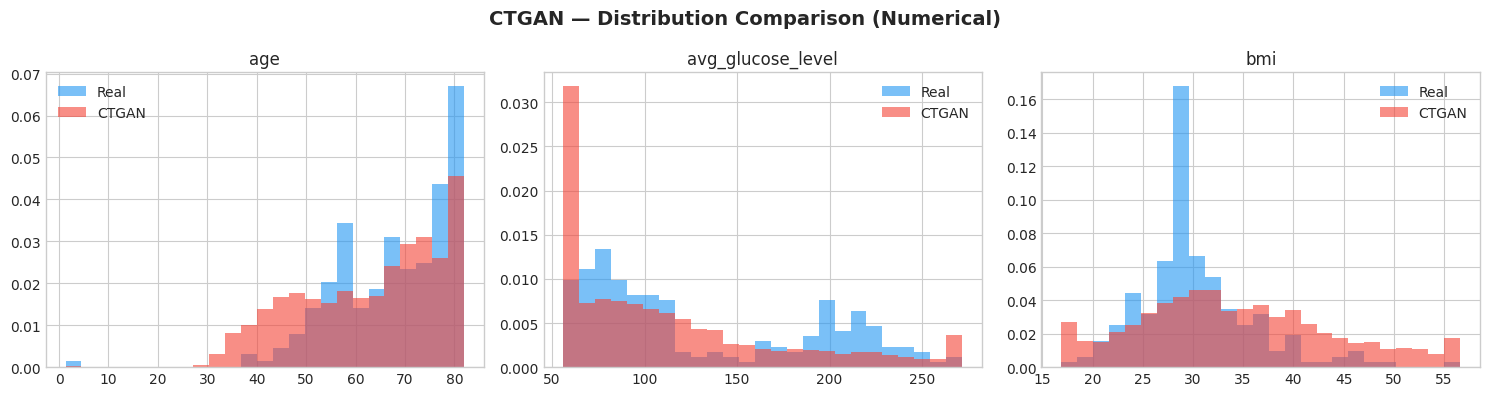

In [7]:
num_features = ['age', 'avg_glucose_level', 'bmi']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feat in zip(axes, num_features):
    ax.hist(minority_train[feat], bins=25, alpha=0.6, label='Real',  color='#2196F3', density=True)
    ax.hist(synthetic_ctgan[feat], bins=25, alpha=0.6, label='CTGAN', color='#F44336', density=True)
    ax.set_title(feat)
    ax.legend()

plt.suptitle('CTGAN — Distribution Comparison (Numerical)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/ctgan_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Basic statistics comparison
print('=== Statistics Comparison ===')
for feat in num_features:
    real_mean = minority_train[feat].mean()
    synt_mean = synthetic_ctgan[feat].mean()
    real_std  = minority_train[feat].std()
    synt_std  = synthetic_ctgan[feat].std()
    print(f'{feat}:')
    print(f'  Real:  mean={real_mean:.2f}, std={real_std:.2f}')
    print(f'  CTGAN: mean={synt_mean:.2f}, std={synt_std:.2f}')

=== Statistics Comparison ===
age:
  Real:  mean=67.66, std=11.88
  CTGAN: mean=62.93, std=14.26
avg_glucose_level:
  Real:  mean=131.39, std=62.13
  CTGAN: mean=112.69, std=59.35
bmi:
  Real:  mean=30.13, std=5.85
  CTGAN: mean=34.23, std=9.64


## 4. TVAE

**TVAE (Tabular Variational Autoencoder):** VAE-based approach. Instead of a GAN (generator vs discriminator), it uses an encoder-decoder architecture. Generally more stable to train than a GAN.

### 4.1 Train TVAE

In [9]:
tvae = TVAESynthesizer(
    metadata,
    epochs=300,
    verbose=True
)

tvae.fit(minority_train)
print('\nTVAE training complete.')

/home/cmakri/.local/lib/python3.10/site-packages/sdv/single_table/base.py:178: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.



  0%|          | 0/300 [00:00<?, ?it/s]

Loss: +00.00:   0%|          | 0/300 [00:00<?, ?it/s]

Loss: +27.05:   0%|          | 0/300 [00:00<?, ?it/s]

Loss: +24.20:   0%|          | 0/300 [00:00<?, ?it/s]

...

Loss: +08.65:  99%|█████████▉| 298/300 [00:03<00:00, 89.80it/s]

Loss: +08.82:  99%|█████████▉| 298/300 [00:03<00:00, 89.80it/s]

Loss: +08.90:  99%|█████████▉| 298/300 [00:03<00:00, 89.80it/s]

Loss: +08.90: 100%|██████████| 300/300 [00:03<00:00, 90.12it/s]


TVAE training complete.


### 4.2 Generate & Quality Check

Generated 3689 synthetic stroke samples


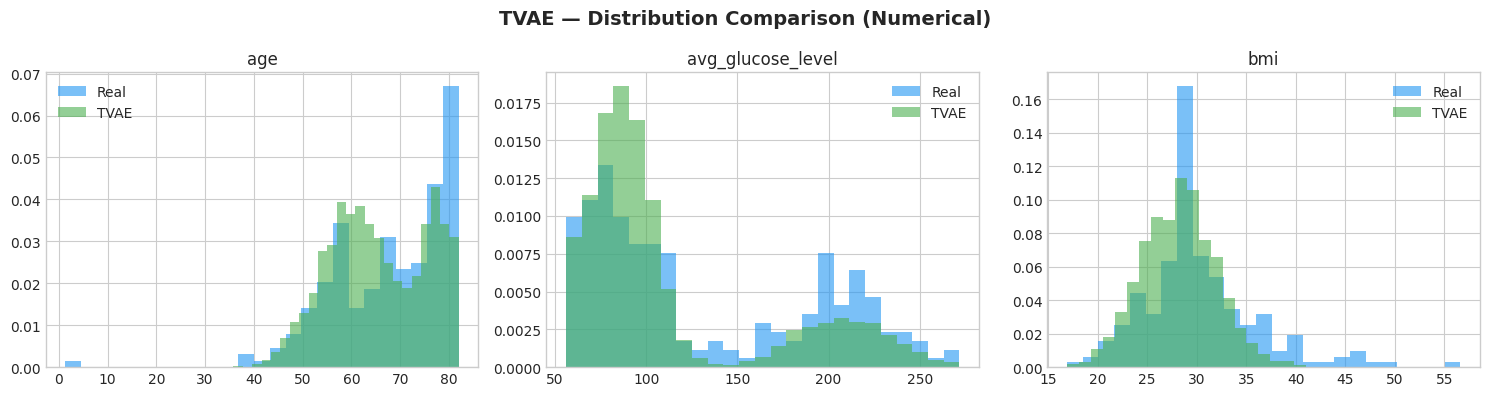

In [10]:
synthetic_tvae = tvae.sample(num_rows=n_to_generate)
synthetic_tvae['stroke'] = 1

print(f'Generated {len(synthetic_tvae)} synthetic stroke samples')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feat in zip(axes, num_features):
    ax.hist(minority_train[feat], bins=25, alpha=0.6, label='Real', color='#2196F3', density=True)
    ax.hist(synthetic_tvae[feat], bins=25, alpha=0.6, label='TVAE', color='#4CAF50', density=True)
    ax.set_title(feat)
    ax.legend()

plt.suptitle('TVAE — Distribution Comparison (Numerical)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/tvae_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
print('=== Statistics Comparison ===')
for feat in num_features:
    real_mean = minority_train[feat].mean()
    synt_mean = synthetic_tvae[feat].mean()
    real_std  = minority_train[feat].std()
    synt_std  = synthetic_tvae[feat].std()
    print(f'{feat}:')
    print(f'  Real: mean={real_mean:.2f}, std={real_std:.2f}')
    print(f'  TVAE: mean={synt_mean:.2f}, std={synt_std:.2f}')

=== Statistics Comparison ===
age:
  Real: mean=67.66, std=11.88
  TVAE: mean=65.53, std=9.92
avg_glucose_level:
  Real: mean=131.39, std=62.13
  TVAE: mean=112.86, std=53.62
bmi:
  Real: mean=30.13, std=5.85
  TVAE: mean=28.18, std=3.79


## 5. Augment & Classify

For each generative model:
1. Combine real train data with synthetic stroke samples
2. Apply encoding + scaling (same pipeline as notebook 2)
3. Train LR + RF on the augmented dataset
4. Evaluate on the **untouched test set**

In [12]:
NUMERICAL   = ['age', 'avg_glucose_level', 'bmi']
CATEGORICAL = ['hypertension', 'heart_disease', 'gender', 'ever_married',
               'work_type', 'Residence_type', 'smoking_status']

def build_Xy(df_raw):
    """Encode categoricals and prepare feature matrix from raw dataframe."""
    d = df_raw.copy()
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    d[CATEGORICAL] = enc.fit_transform(d[CATEGORICAL])
    X = d[NUMERICAL + CATEGORICAL].values
    y = d['stroke'].values
    return X, y, enc

def scale_split(X_tr, X_te):
    """Apply StandardScaler to numerical columns only."""
    scaler = StandardScaler()
    n = len(NUMERICAL)
    X_tr_s = np.hstack([scaler.fit_transform(X_tr[:, :n]), X_tr[:, n:]])
    X_te_s = np.hstack([scaler.transform(X_te[:, :n]),     X_te[:, n:]])
    return X_tr_s, X_te_s

results = []

def evaluate(method, clf_name, clf, X_tr, y_tr, X_te, y_te):
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    y_prob = clf.predict_proba(X_te)[:, 1]
    f1     = f1_score(y_te, y_pred)
    pr_auc = average_precision_score(y_te, y_prob)
    mcc    = matthews_corrcoef(y_te, y_pred)
    print(f'\n[{method}] {clf_name}')
    print(f'  F1: {f1:.4f} | PR-AUC: {pr_auc:.4f} | MCC: {mcc:.4f}')
    print(classification_report(y_te, y_pred, target_names=['No Stroke', 'Stroke']))
    results.append({'Method': method, 'Classifier': clf_name,
                    'F1': round(f1,4), 'PR-AUC': round(pr_auc,4), 'MCC': round(mcc,4)})

# Encode test set (fit encoder on train to avoid leakage)
X_train_raw, y_train_raw, enc_train = build_Xy(train_df)
X_test_raw  = enc_train.transform(test_df[CATEGORICAL].values)
X_test_full = np.hstack([test_df[NUMERICAL].values, X_test_raw])
y_test      = test_df['stroke'].values

/home/cmakri/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning:

X does not have valid feature names, but OrdinalEncoder was fitted with feature names



In [13]:
# --- CTGAN Augmentation ---
train_ctgan = pd.concat([train_df, synthetic_ctgan], ignore_index=True)

X_tr_ctgan, y_tr_ctgan, enc_ctgan = build_Xy(train_ctgan)
X_te_ctgan = np.hstack([test_df[NUMERICAL].values,
                         enc_ctgan.transform(test_df[CATEGORICAL].values)])

X_tr_ctgan_s, X_te_ctgan_s = scale_split(X_tr_ctgan, X_te_ctgan)

print(f'Augmented train (CTGAN): {train_ctgan.shape} | Stroke: {y_tr_ctgan.sum()} ({y_tr_ctgan.mean()*100:.1f}%)')

evaluate('CTGAN', 'Logistic Regression',
         LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
         X_tr_ctgan_s, y_tr_ctgan, X_te_ctgan_s, y_test)

evaluate('CTGAN', 'Random Forest',
         RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
         X_tr_ctgan_s, y_tr_ctgan, X_te_ctgan_s, y_test)

Augmented train (CTGAN): (7776, 11) | Stroke: 3888 (50.0%)

[CTGAN] Logistic Regression
  F1: 0.2308 | PR-AUC: 0.2009 | MCC: 0.2619
              precision    recall  f1-score   support

   No Stroke       0.99      0.72      0.83       972
      Stroke       0.13      0.84      0.23        50

    accuracy                           0.73      1022
   macro avg       0.56      0.78      0.53      1022
weighted avg       0.95      0.73      0.80      1022



/home/cmakri/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning:

X does not have valid feature names, but OrdinalEncoder was fitted with feature names




[CTGAN] Random Forest
  F1: 0.2238 | PR-AUC: 0.1133 | MCC: 0.2202
              precision    recall  f1-score   support

   No Stroke       0.98      0.79      0.87       972
      Stroke       0.14      0.64      0.22        50

    accuracy                           0.78      1022
   macro avg       0.56      0.72      0.55      1022
weighted avg       0.94      0.78      0.84      1022



In [14]:
# --- TVAE Augmentation ---
train_tvae = pd.concat([train_df, synthetic_tvae], ignore_index=True)

X_tr_tvae, y_tr_tvae, enc_tvae = build_Xy(train_tvae)
X_te_tvae = np.hstack([test_df[NUMERICAL].values,
                        enc_tvae.transform(test_df[CATEGORICAL].values)])

X_tr_tvae_s, X_te_tvae_s = scale_split(X_tr_tvae, X_te_tvae)

print(f'Augmented train (TVAE): {train_tvae.shape} | Stroke: {y_tr_tvae.sum()} ({y_tr_tvae.mean()*100:.1f}%)')

evaluate('TVAE', 'Logistic Regression',
         LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
         X_tr_tvae_s, y_tr_tvae, X_te_tvae_s, y_test)

evaluate('TVAE', 'Random Forest',
         RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
         X_tr_tvae_s, y_tr_tvae, X_te_tvae_s, y_test)

Augmented train (TVAE): (7776, 11) | Stroke: 3888 (50.0%)

[TVAE] Logistic Regression
  F1: 0.1507 | PR-AUC: 0.1392 | MCC: 0.1084
              precision    recall  f1-score   support

   No Stroke       0.96      0.77      0.86       972
      Stroke       0.09      0.44      0.15        50

    accuracy                           0.76      1022
   macro avg       0.53      0.61      0.50      1022
weighted avg       0.92      0.76      0.82      1022



/home/cmakri/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning:

X does not have valid feature names, but OrdinalEncoder was fitted with feature names




[TVAE] Random Forest
  F1: 0.1342 | PR-AUC: 0.1011 | MCC: 0.0791
              precision    recall  f1-score   support

   No Stroke       0.96      0.91      0.93       972
      Stroke       0.10      0.20      0.13        50

    accuracy                           0.87      1022
   macro avg       0.53      0.55      0.53      1022
weighted avg       0.91      0.87      0.89      1022



## 6. Results Summary

In [15]:
results_df = pd.DataFrame(results).sort_values('F1', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

Method          Classifier     F1  PR-AUC    MCC
 CTGAN Logistic Regression 0.2308  0.2009 0.2619
 CTGAN       Random Forest 0.2238  0.1133 0.2202
  TVAE Logistic Regression 0.1507  0.1392 0.1084
  TVAE       Random Forest 0.1342  0.1011 0.0791


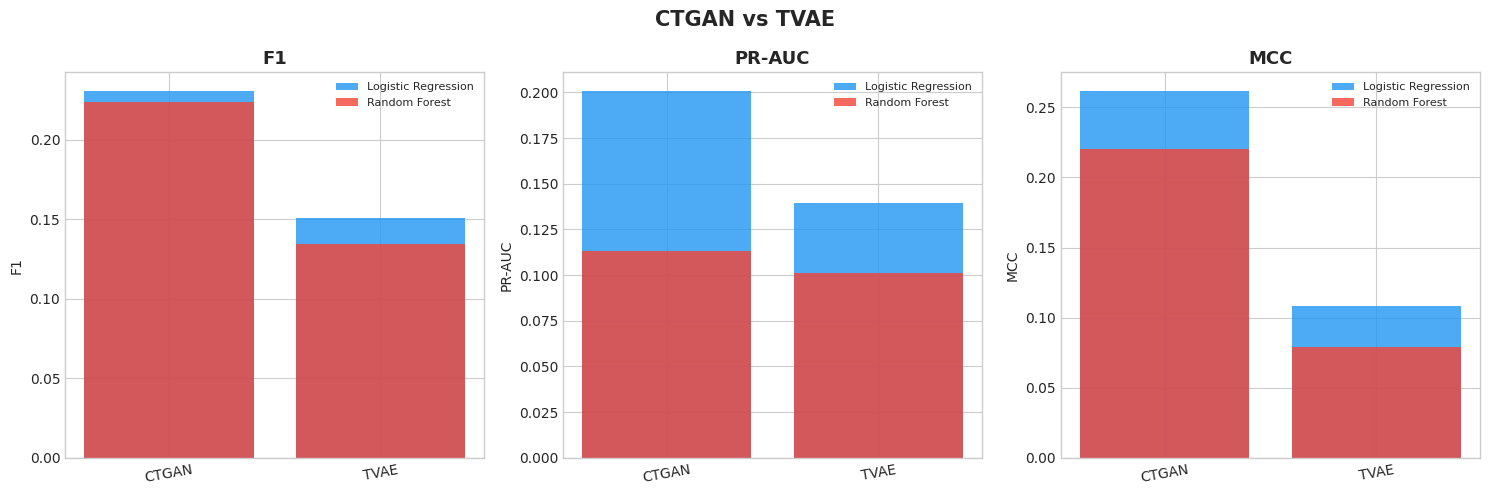

In [16]:
metrics = ['F1', 'PR-AUC', 'MCC']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = {'Logistic Regression': '#2196F3', 'Random Forest': '#F44336'}

for ax, metric in zip(axes, metrics):
    for clf_name, grp in results_df.groupby('Classifier'):
        x = np.arange(len(grp))
        ax.bar(
            grp['Method'].values,
            grp[metric].values,
            label=clf_name,
            alpha=0.8,
            color=colors[clf_name]
        )
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=10)
    ax.legend(fontsize=8)

plt.suptitle('CTGAN vs TVAE', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/ctgan_tvae_results.png', dpi=150, bbox_inches='tight')
plt.show()